# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad

# frank1d
from frank.utilities import UVDataBinner

# Data

In [5]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [6]:
data = AS209

dir = "/Users/mariajmelladot/Desktop/Frank2D/data/uvtables/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

In [7]:
# Frank Parameters
N = 300
 # load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

# F2D

### study the input

In [8]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, r_out, geom)

In [9]:
frank2d.process_vis(u, v, Vis, Weights)

/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d/frank2d/preprocess_vis.py:129: RuntimeWarning: invalid value encountered in divide
  vis_gridded_matrix =  vis_weights_sum_bin/weights_gridded_matrix


Shifted grid..
Setting gridded data...


In [10]:
# Let's review the input for frank2d.

#### uv plane

In [227]:
input =  frank2d.gridded_data
u_g, v_g, vis_g, weights_g = input["u"], input["v"], input["vis"], input["weights"]

u_g, v_g = u_g.reshape(N, N), v_g.reshape(N, N)
vis_g = vis_g.reshape(N, N)

v_g_flip = np.flip(v_g_, axis = 0)
u_g_flip = np.flip(u_g_, axis = 1)

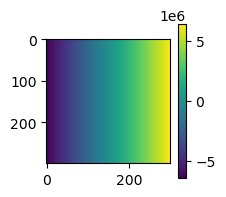

In [228]:
plt.figure(figsize=(2, 2))
plt.imshow(u_g)
plt.colorbar()
plt.show()

In [229]:
ud, vd, _ = geom.deproject(u_g, v_g)

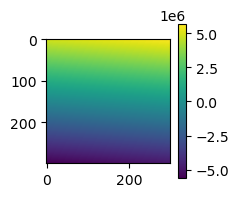

In [230]:
plt.figure(figsize=(2, 2))
plt.imshow(ud)
plt.colorbar()
plt.show()

In [190]:
vis_shifted_phase_shifted = geom.apply_phase_shift(u_shifted, v_shifted, vis_shifted)

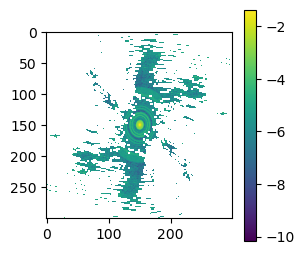

In [240]:
plt.figure(figsize=(3, 3))
plt.imshow(np.log(np.abs(vis_shifted)))
plt.colorbar()
plt.show()

#### imshow

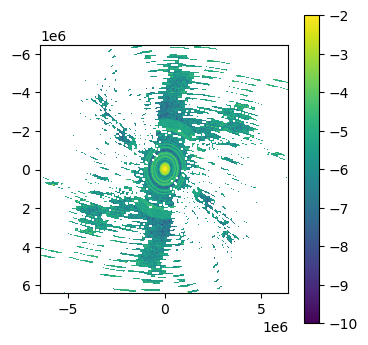

In [196]:
plt.figure(figsize=(4, 4))
plt.imshow(np.log(np.abs(vis_shifted)), 
           extent = [u_shifted_1d[0], u_shifted_1d[-1], v_shifted_1d[-1], v_shifted_1d[0]],
           vmin=-10, vmax=-2
          )
plt.colorbar()
plt.show()

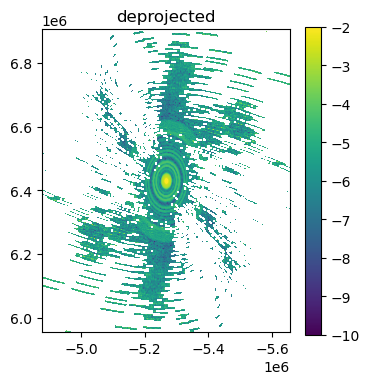

In [197]:
plt.figure(figsize=(4, 4))
plt.imshow(np.log(np.abs(vis_shifted)), 
           extent = [ud[0][0], ud[0][-1], vd[-1][0], vd[0][0]], 
           vmin=-10, vmax=-2
          )
plt.title("deprojected")
plt.colorbar()
plt.show()

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(np.log(np.abs(vis_shifted)), 
           extent = [ud_1d[0], ud_1d[-1], vd_1d[-1], vd_1d[0]],
           vmin=-10, vmax=-2
          )
plt.title("deprojected")
plt.colorbar()
plt.show()

In [ ]:
# convention.

In [ ]:
v_shifted_flipped = np.flip(v_shifted, axis = 0)
u_shifted_flipped = np.flip(u_shifted, axis = 1)
vis_shifted_flipped = np.flip(vis_shifted, axis = (0,1))

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(np.log(np.abs(vis_shifted_flipped)), 
           extent = [u_shifted_flipped[0][0], u_shifted_flipped[0][-1], v_shifted_flipped[-1][0], v_shifted_flipped[0][0]], 
           vmin=-10, vmax=-2
          )
plt.colorbar()
plt.show()

In [ ]:
u_shifted_flipped_1d = -u_shifted_1d
v_shifted_flipped_1d = -v_shifted_1d

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(np.log(np.abs(vis_shifted_flipped)), 
           extent = [u_shifted_flipped_1d[0], u_shifted_flipped_1d[-1], v_shifted_flipped_1d[-1], v_shifted_flipped_1d[0]], 
           vmin=-10, vmax=-2
          )
plt.colorbar()
plt.show()

#### pcolormesh

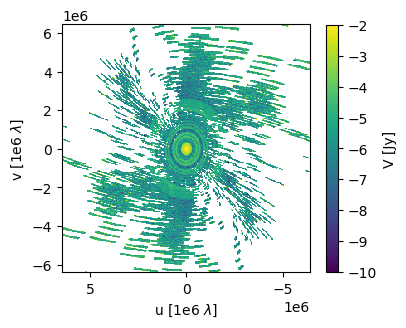

In [255]:
plt.figure(figsize= (4, 4))
u, v = -u_g, -v_g
plt.pcolormesh(u,
               v,
               np.log(np.abs(vis_shifted)),
               cmap="viridis",
               vmin=-10, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{gridded}$|')
cmap = plt.colorbar(shrink=0.8)
plt.title("")
cmap.set_label(r'V [Jy]', size=10)

# Límites de ejes:
plt.xlim(u.max(), u.min())
plt.ylim(v.max(), v.min())

plt.gca().set_aspect(1)
plt.gca().invert_yaxis()
#plt.gca().invert_xaxis()
plt.show()

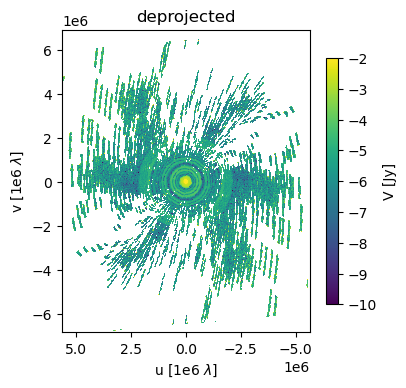

In [256]:
plt.figure(figsize= (4, 4))
u, v = ud, vd
plt.pcolormesh(u,
               v,
               np.log(np.abs(vis_shifted)),
               cmap="viridis",
               vmin=-10, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{gridded}$|')
cmap = plt.colorbar(shrink=0.8)
plt.title("deprojected")
cmap.set_label(r'V [Jy]', size=10)

u, v = -ud, -vd
# Límites de ejes:
plt.xlim(u.max(), u.min())
plt.ylim(v.max(), v.min())

plt.gca().set_aspect(1)
plt.gca().invert_yaxis()
#plt.gca().invert_xaxis()
plt.show()

### Run

In [8]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

In [9]:
frank2d.process_vis(u, v, Vis, Weights)

Shifted grid..
Setting gridded data...


Setting GP Kernel Wendland...
Creating sparse linear system...
--> time = 0.61  min |  36.84 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 2.881751982790495
Final tolerance :  2.881751982790495
.... iteration:  0
                        -> actual tol:  288175198.2790495 vs  2.881751982790495
.... iteration:  1
                        -> actual tol:  39773051.282940544 vs  2.881751982790495
.... iteration:  2
                        -> actual tol:  30605898.285020255 vs  2.881751982790495
.... iteration:  3
                        -> actual tol:  31458951.244836483 vs  2.881751982790495
.... iteration:  4
                        -> actual tol:  32660086.132000692 vs  2.881751982790495
.... iteration:  5
                        -> actual tol:  32037725.273025826 vs  2.881751982790495
.... iteration:  6
                        -> actual tol:  68809248.88808323 vs  2.881751982790495
.... iteration:  7
                        -> actual tol:  30549785.13

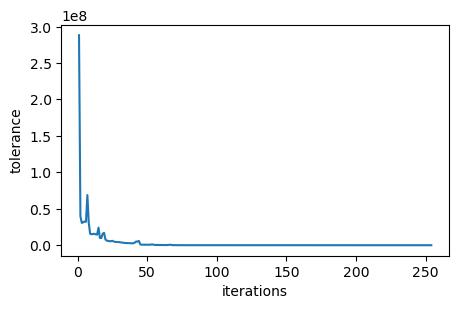

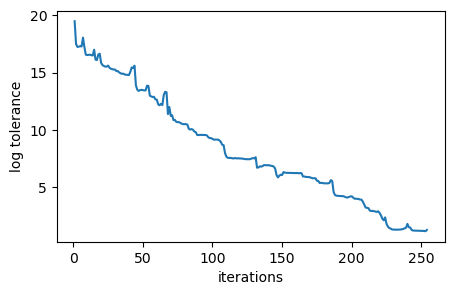

--> time = 0.12  min |  7.03 seconds
-> CGM converged?   True
-> Fit correctly?   True
!!!!  Sucess  !!!!
Building full visibility model...
F2D model in 2.44 minutes.


In [10]:
start_time = time.time()

kernel_params =  {'m': -2, 'c': 1e8, 'l': 7e4}
frank2d.fit(kernel_params = kernel_params, rtol = 1e-8 )

end_time = time.time()
print(f"F2D model in {(end_time - start_time)/60:.2f} minutes.")

# Plot

In [11]:
import matplotlib.colors as colors

### Explore

In [59]:
u, v = frank2d.u, frank2d.v
x, y = frank2d.x, frank2d.y
vis = frank2d.visibility_model

u_grid, v_grid = frank2d.u_grid, frank2d.v_grid

#### imshow

In [12]:
extent_uv_convention = [-u[0], -u[-1], -v[-1], -v[0]]
extent_uv_original = [u[0],  u[-1], v[-1], v[0]]

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_32202/942510069.py:2: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(frank2d.visibility_model)),


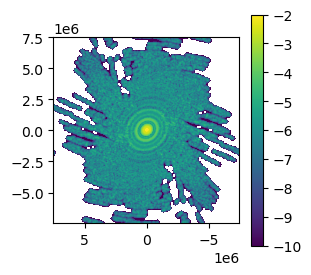

In [13]:
plt.figure(figsize=(3, 3))
plt.imshow(np.log(np.abs(frank2d.visibility_model)), 
          extent=extent_uv_convention, cmap="viridis",
               vmin=-10, vmax=-2)
plt.colorbar()

In [18]:
extent_xy_convention = np.array([-x[0], -x[-1], -y[-1], -y[0]])*rad_to_arcsec
extent_xy_original = np.array([x[0],  x[-1], y[-1], y[0]])*rad_to_arcsec

In [19]:
int = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis)))/(frank2d._FT._dx * frank2d._FT._dy)
int = int.real

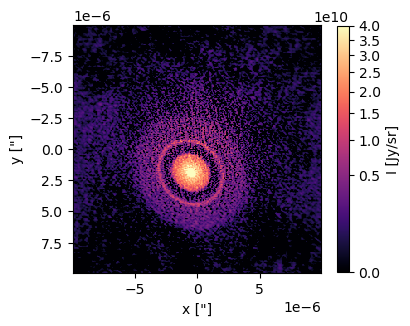

In [20]:
plt.figure(figsize= (4, 4))

norm = colors.PowerNorm(gamma=0.45, vmin=0, vmax=4e10)
plt.pcolormesh(x,
               y,
               int,
               cmap="magma",
               norm=norm)
plt.xlabel(r'x ["]')
plt.ylabel(r'y ["]')
cmap = plt.colorbar(shrink=0.8)
plt.title("")
cmap.set_label(r'I [Jy/sr]', size=10)

lim = 1.5
# Límites de ejes:
plt.xlim(x.min(), x.max())
plt.ylim(y.min(), y.max())

plt.gca().set_aspect(1)
plt.gca().invert_yaxis()
plt.show()

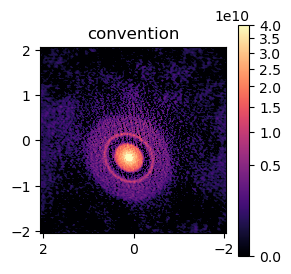

In [21]:
import matplotlib.colors as colors
plt.figure(figsize=(3, 3))
norm = colors.PowerNorm(gamma=0.45, vmin=0, vmax=4e10)
plt.imshow(int,  extent = extent_xy_convention,
           cmap='magma',norm=norm, origin='upper')
plt.title("convention")
plt.colorbar()


In [38]:
def deproject_uv(frank2d, u, v):
    inc = frank2d._Geometry._inc*deg_to_rad
    pa = (frank2d._Geometry._pa)*deg_to_rad

    cos_t = np.cos(pa)
    sin_t = np.sin(pa)

    up = u * cos_t - v * sin_t
    vp = u * sin_t + v * cos_t

    up = up * np.cos(inc)

    return up, vp

In [42]:
ud, vd = deproject_uv(frank2d, u_grid, v_grid)

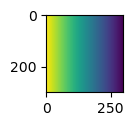

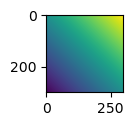

In [43]:
plt.figure(figsize=(1, 1))
plt.imshow(-u_grid)
plt.show()

plt.figure(figsize=(1, 1))
plt.imshow(ud)
plt.show()

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_32202/1137116792.py:5: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis)),


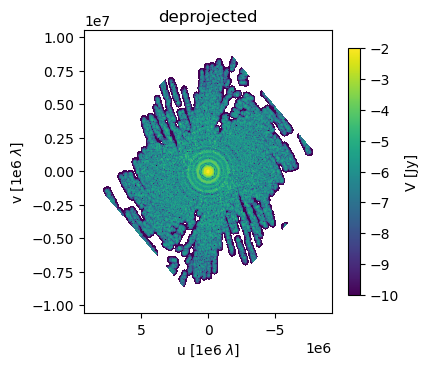

In [44]:
plt.figure(figsize= (4, 4))
u, v = ud, vd
plt.pcolormesh(u,
               v,
               np.log(np.abs(vis)),
               cmap="viridis",
               vmin=-10, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{gridded}$|')
cmap = plt.colorbar(shrink=0.8)
plt.title("deprojected")
cmap.set_label(r'V [Jy]', size=10)

#u, v = -ud, -vd
# Límites de ejes:
plt.xlim(u.max(), u.min())
plt.ylim(v.max(), v.min())

plt.gca().set_aspect(1)
plt.gca().invert_yaxis()
#plt.gca().invert_xaxis()
plt.show()

##### phase shifting

In [81]:
u_, v_ = (-u_grid).ravel(order ='C'), (-v_grid).ravel(order ='C')
vis_ = vis.ravel(order ='C')

In [82]:
vis_shifted_ = geom.apply_phase_shift(u_, v_, vis_).reshape(N, N)

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_32836/288295106.py:4: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted_)),


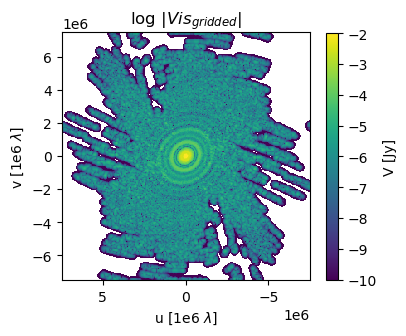

In [75]:
plt.figure(figsize= (4, 4))
plt.pcolormesh(u_grid,
               v_grid,
               np.log(np.abs(vis_shifted_)),
               cmap="viridis",
               vmin=-10, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{gridded}$|')
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'V [Jy]', size=10)

#u, v = -ud, -vd
# Límites de ejes:
plt.xlim(u.max(), u.min())
plt.ylim(v.max(), v.min())

plt.gca().set_aspect(1)
plt.gca().invert_yaxis()
#plt.gca().invert_xaxis()
plt.show()

In [46]:
vis_shifted = geom.apply_phase_shift(-u_grid, -v_grid, vis)

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_32202/4154964860.py:5: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


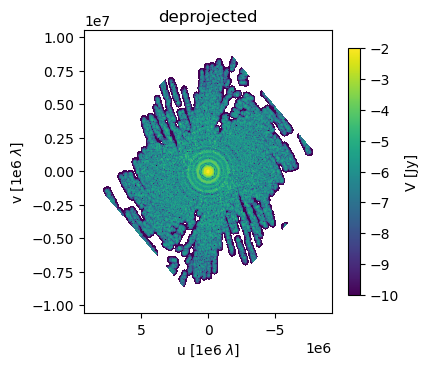

In [48]:
plt.figure(figsize= (4, 4))
u, v = ud, vd
plt.pcolormesh(u,
               v,
               np.log(np.abs(vis_shifted)),
               cmap="viridis",
               vmin=-10, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{gridded}$|')
cmap = plt.colorbar(shrink=0.8)
plt.title("deprojected")
cmap.set_label(r'V [Jy]', size=10)

#u, v = -ud, -vd
# Límites de ejes:
plt.xlim(u.max(), u.min())
plt.ylim(v.max(), v.min())

plt.gca().set_aspect(1)
plt.gca().invert_yaxis()
#plt.gca().invert_xaxis()
plt.show()

In [83]:
int_shifted = np.fft.fftshift(np.fft.ifft2(np.fft.fftshift(vis_shifted_))).real/(frank2d._FT._dx * frank2d._FT._dy)

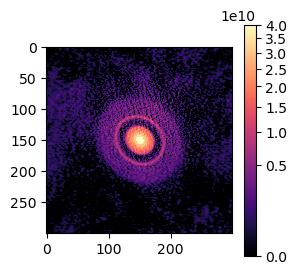

In [84]:
plt.figure(figsize=(3, 3))
norm = colors.PowerNorm(gamma=0.45, vmin=0, vmax=4e10)
plt.imshow(int_shifted, cmap='magma',norm=norm)
plt.colorbar()

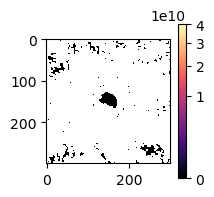

In [410]:
plt.figure(figsize=(2, 2))
norm = colors.PowerNorm(gamma=0.45, vmin=0, vmax=4e10)
plt.imshow(np.log(int_shifted - int), cmap='magma',norm=norm)
plt.colorbar()

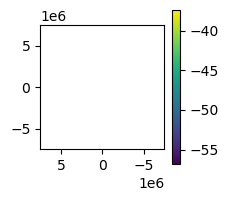

In [411]:
plt.figure(figsize=(2, 2))
plt.imshow(np.log(np.abs(vis) -np.abs(vis_shifted)), 
          extent=extent_uv_convention)
plt.colorbar()

#### colormesh

In [133]:
def deproject_xy(frank2d, x, y):
    inc = frank2d._Geometry._inc*deg_to_rad
    pa = (frank2d._Geometry._pa-90)*deg_to_rad

    cos_i = np.cos(inc)
    cos_pa, sin_pa = np.cos(pa), np.sin(pa)

    x_d = (x * cos_pa + y * sin_pa)
    y_d = (x *-sin_pa + y * cos_pa)

    x_d = x_d/cos_i
    return x_d, y_d

In [80]:
x, y = frank2d.x_grid, frank2d.y_grid
xd, yd = deproject_xy(frank2d, x, y)

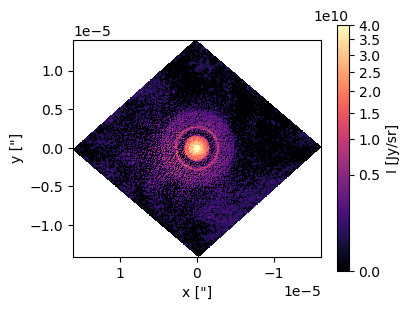

In [81]:
plt.figure(figsize= (4, 4))

x, y = xd, yd
norm = colors.PowerNorm(gamma=0.45, vmin=0, vmax=4e10)
plt.pcolormesh(x,
               y,
               int_shifted,
               cmap="magma",
               norm=norm)
plt.xlabel(r'x ["]')
plt.ylabel(r'y ["]')
cmap = plt.colorbar(shrink=0.8)
plt.title("")
cmap.set_label(r'I [Jy/sr]', size=10)

# Límites de ejes:
plt.xlim(x.max(), x.min())
plt.ylim(y.max(), y.min())

plt.gca().set_aspect(1)
plt.gca().invert_yaxis()
plt.show()

## Fix Plot class

In [51]:
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic
import matplotlib.colors as colors

# frank1d utilities
from frank.utilities import UVDataBinner
from frank.utilities import convolve_profile

from frank2d.constants import rad_to_arcsec, deg_to_rad


from astropy.io import fits
from gofish import imagecube


In [112]:
class Plot(object):
    def __init__(self, Frank2D, Geometry):
        self._frank2d = Frank2D
        self._Geometry = Geometry
        self._FT = Frank2D._FT
        
        self._Nx = self._Ny = Frank2D._N
        
        self._u_input = Frank2D._gridded_data['u']
        self._v_input = Frank2D._gridded_data['v']
        self._vis_input = Frank2D._gridded_data['vis']
        self._weights_input = Frank2D._gridded_data['weights']

        self._u_model = self._frank2d.u_grid
        self._v_model = self._frank2d.v_grid
        self._u_model_1d = self._frank2d.u
        self._v_model_1d = self._frank2d.v
        self._vis_model = Frank2D.visibility_model

        self._x_model = self._frank2d.x_grid*rad_to_arcsec
        self._y_model = self._frank2d.y_grid*rad_to_arcsec
        self._x_model_1d = self._frank2d.x*rad_to_arcsec
        self._y_model_1d = self._frank2d.y*rad_to_arcsec
        self._int_model = Frank2D.intensity_model.real

        self._Rmax = Frank2D.Rmax
        


    def visibility(self, kind = 'model',
                   title=r'$log |Vis|$', fig_size = 3,
                   vmin = -9, vmax = -2,
                   phase_shift = True, deproject = False):
        
        Nx, Ny = self._Nx, self._Ny
        geom = self._Geometry
        vis = None

        if kind == 'input':
            vis = self._vis_input
        elif kind == 'model':
            vis = self._vis_model
        else:
            raise ValueError("type must be 'input' or 'model'")

        # Shifted already.
        u = self._u_model #(N, N)
        v = self._v_model
        if phase_shift:
            # Only in this scheme (East of North) makes sense to do the phase shifting.
            vis = geom.apply_phase_shift(-u, -v, vis)
        
        if deproject: 
            ud, vd, _ = geom.deproject(u, v)
            u, v = ud, vd

        
        plt.figure(figsize = (fig_size, fig_size))
        plt.pcolormesh(u,
                       v,
                       np.log(np.abs(vis)),
                       cmap="magma",
                       vmin=-10, vmax=-2)
        plt.xlabel(r'u [1e6 $\lambda$]')
        plt.ylabel(r'v [1e6 $\lambda$]')
        plt.title(title)
        cmap = plt.colorbar(shrink=0.8)
        cmap.set_label(r'log|Visibility model| [Jy]', size=10)
        
        # This impose the convention East of North.  
        plt.xlim(u.max(), u.min())
        plt.ylim(v.max(), v.min())
        
        plt.gca().set_aspect(1)
        plt.gca().invert_yaxis()
        plt.show()
    
    def intensity(self, title= r'I_{Model}', fig_size = 6, vmin = 0, vmax = 4e10,
                  phase_shift = True, deproject = False):
        
        Nx, Ny = self._Nx, self._Ny
        f2d = self._frank2d
        geom = self._Geometry
        
        I = self._int_model

        u_grid = self._u_model #(N, N)
        v_grid = self._v_model
        if phase_shift:
            # Only in this scheme (East of North) makes sense to do the phase shifting.
            vis_ = self._vis_model
            vis = geom.apply_phase_shift(-u_grid, -v_grid, vis_)
            I = f2d.transform(vis).real
        
        x = self._x_model
        y = self._y_model
        if deproject:
            xd, yd = geom.deproject_xy(x_grid, y_grid)
            x, y = xd, yd
            
        plt.figure(figsize = (fig_size, fig_size))
        norm = colors.PowerNorm(gamma=0.45, vmin=0, vmax=4e10)
        plt.pcolormesh(x,
                       y,
                       I,
                       cmap="magma",
                       norm=norm)
        plt.xlabel(r'x ["]')
        plt.ylabel(r'y ["]')
        cmap = plt.colorbar(shrink=0.8)
        plt.title(title)
        cmap.set_label(r'I [Jy/sr]', size=10)
        
        # This impose the convention East of North.  
        plt.xlim(x.max(), x.min())
        plt.ylim(y.max(), y.min())
        
        plt.gca().set_aspect(1)
        plt.gca().invert_yaxis()
        plt.show()

    def get_profile(self, u, v, vis, bins, weighted = False, weights = None):
        from scipy.stats import binned_statistic
        
        q = np.hypot(u, v)

        q = q.ravel(order = 'C')
        vis = vis.ravel(order = 'C')
        
        if weighted:
            if weights is None:
                raise ValueError("Add weights.")
            weights_gridded = self._weights_input
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, vis*weights_gridded, 'sum', bins = bins)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = bins)

            vis_1d = np.nan_to_num(Vis_Weights_binned, nan=0)
            vis_1d = vis_1d/Weights_binned
        else:
            vis_1d, bin_edges, _ = binned_statistic(q, vis, 'mean', bins = bins)
        
        q_1d = (bin_edges[:-1] + bin_edges[1:]) / 2
            
        return q_1d, vis_1d

    def edges(self, x):
        mids = (x[1:] + x[:-1]) / 2.0
        first = x[0]  - (x[1] - x[0]) / 2.0
        last  = x[-1] + (x[-1] - x[-2]) / 2.0
        return np.r_[first, mids, last]


    def  visibility_profile(self, input = None, frank1d = False, weighted = True, bins = 300,
                    phase_shift = True, deproject = True):

        geom = self._Geometry
        # model
        u_model = self._u_model
        v_model = self._v_model
        vis_model = self._vis_model
        
        u_model_1d = self._u_model_1d
        v_model_1d = self._v_model_1d

        # input
        u_input_g = self._u_input
        v_input_g = self._v_input
        vis_input_g = self._vis_input
        weights_input_g = self._weights_input
        
        if input is not None:
            u_input = input['u']
            v_input = input['v']
            vis_input = input['vis']
            weights_input = input['weights']
        else:
            u_input = u_input_g
            v_input = v_input_g
            vis_input = vis_input_g
            weights_input = weights_input_g
            
        if phase_shift:
            # is necessary to be done in the East of North convention.
            vis_input = geom.apply_phase_shift(-u_input, -v_input, vis_input)
            vis_model = geom.apply_phase_shift(-u_model, -v_model, vis_model)
        
        if deproject:
            u_model, v_model, _ = geom.deproject(u_model, v_model)
            u_model_1d, v_model_1d, _ = geom.deproject(u_model_1d, v_model_1d)
            u_input, v_input, _ = geom.deproject(u_input, v_input)

        # collocation points for the plot.
        q = np.unique(np.hypot(u_model_1d, v_model_1d))
        q = np.linspace(q.min(), q.max(), bins)
        edges = self.edges(q)

        # f1d
        if frank1d:
            #frank1d
            u_input_f1d = u_input_g
            v_input_f1d = v_input_g
            vis_input_f1d = vis_input_g
            weights_input_f1d = weights_input_g
            
            sol = self._frank2d.frank1d(u = u_input_f1d, v = v_input_f1d,
                                        vis = vis_input_f1d, weights = weights_input_f1d,
                                        n_pts = self._Nx)

            if deproject:
                vis_f1d = sol.predict_deprojected(q = q)
            else:
                vis_f1d = sol._vis_map.predict_visibilities(sol.mean, q, q*0, geometry=self._Geometry )

        # rescale total flux
        def rescale_total_flux(vis, weights):
            vis = vis / np.cos(geom.inc * deg_to_rad)
            weights = weights * np.cos(geom.inc * deg_to_rad) ** 2
            return vis, weights

        vis_model_scaled, weights_scaled = rescale_total_flux(vis_model, weights_input)
        vis_input, weights_input = rescale_total_flux(vis_input, weights_input)

        q_model_1d, vis_model_1d = self.get_profile(u_model, v_model, vis_model_scaled,
                                                    bins = edges,
                                                    weighted = weighted, weights = weights_scaled)

        # ----------------
        baselines = np.hypot(u_input, v_input)         
        grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                                   np.log10(max(baselines.max(), baselines[-1])),
                                   10**4)
        
        
        plt.figure(figsize=(10,4))
        # Raw visibilities ---------------------------------------------------------
        cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
        bin_widths = [1e3, 1e5]

        binned_vis0 = UVDataBinner(baselines, vis_input, weights_input, bin_widths[0])
        plt.plot(binned_vis0.uv, np.abs(binned_vis0.V), c=cs[0],
                     marker=ms[0], ls='None', 
                     label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
        
        binned_vis1 = UVDataBinner(baselines, vis_input, weights_input, bin_widths[1])
        plt.plot(binned_vis1.uv, np.abs(binned_vis1.V), c=cs[1],
                     marker=ms[1], ls='None', 
                     label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))
    
        # frank1D -------------------------------------------------------------------
        if frank1d:
            plt.plot(q, np.abs(vis_f1d), color = "red", label = r'frank1d')
    
        # frank2D -------------------------------------------------------------------
        plt.plot(q, np.abs(vis_model_1d), color = 'blue', ls ='--', label = r'frank2d')
    
        plt.xlabel(r'baseline [$\lambda$]')
        plt.xscale('log')
        plt.yscale('log')
        plt.ylim(1e-5, 0)
        plt.xlim(1e5, 6e6)
        plt.ylabel('|V| [Jy]', size = 10)
        plt.title(r'$Visibility_{Model}$ N = ' + str(self._Nx))
        plt.legend(fontsize= 10, loc = 'best')
        plt.show()

    def intensity_profile(self, title= r'Brightness profile', 
                          clean = False, fits_file = None,
                          frank1d = True, bins = 300,
                          phase_shift = True, deproject = True):
        
        geom = self._Geometry
        inc, pa, dra, ddec = geom.inc, geom.pa, geom.dra, geom.ddec

        if clean:
            if fits_file is None:
                raise ValueError("Data location for the FITS file to make the CLEAN profile is not provided.")
            else:
                cube_1mm = imagecube(fits_file)
                x_clean, y_clean, dy_clean = cube_1mm.radial_profile(inc= inc, PA=pa, x0=dra, y0=ddec)
                
                fits_image = fits.open(fits_file)
                header = fits_image[0].header
                bmaj_deg = float(header["BMAJ"])
                bmin_deg = float(header["BMIN"])
                bmaj_as = bmaj_deg * 3600.0
                bmin_as = bmin_deg * 3600.0
                bpa_deg = header['BPA']
                
                clean_beam = {'bmaj': bmaj_as, 'bmin': bmin_as, 'beam_pa': bpa_deg}
                area = clean_beam['bmaj']*clean_beam['bmin']*np.pi/4./np.log(2.)*(1/rad_to_arcsec)**2

        # input
        u_input_g = self._u_input
        v_input_g = self._v_input
        vis_input_g = self._vis_input
        weights_input_g = self._weights_input

        # model
        u_model = self._u_model
        v_model = self._v_model
        vis_model = self._vis_model
        
        u_model_1d = self._u_model_1d
        v_model_1d = self._v_model_1d

        x_model = self._x_model
        y_model = self._y_model

        x_model_1d = self._x_model_1d
        y_model_1d = self._y_model_1d
        
        # phase shift
        vis = geom.apply_phase_shift(-u_model, -v_model, vis_model) # the East of North convention.
        I = frank2d.transform(vis).real

        # deproject
        x_model, y_model = geom.deproject_xy(x_model, y_model)
        x_model_1d, y_model_1d = geom.deproject_xy(x_model_1d, y_model_1d)

        # collocation points for the plot.
        r = np.unique(np.hypot(x_model_1d, y_model_1d))
        r = np.linspace(r.min(), r.max(), bins)
        edges = self.edges(r)

        # f1d
        if frank1d:
            #frank1d
            u_input_f1d = u_input_g
            v_input_f1d = v_input_g
            vis_input_f1d = vis_input_g
            weights_input_f1d = weights_input_g
            
            sol = self._frank2d.frank1d(u = u_input_f1d, v = v_input_f1d,
                                        vis = vis_input_f1d, weights = weights_input_f1d,
                                        n_pts = self._Nx)

            I_f1d = sol.mean
            r_f1d = sol.r

        r_model_1d, I_model_1d = self.get_profile(x_model, y_model, I, bins = edges)
        I_model_1d = np.nan_to_num(I_model_1d, nan=0)/np.cos(inc*deg_to_rad)
        
        plt.figure(figsize=(10,4))
        if clean:
            #  CLEAN --------------------------------------------------------------------
            plt.plot(x_clean, y_clean, "black", label = "CLEAN")
            plt.fill_between(x_clean, y_clean-dy_clean, y_clean+dy_clean, alpha=0.7)
            # frank2D -------------------------------------------------------------------
            I_model_1d_convolved = convolve_profile(r_model_1d, I_model_1d, inc, pa, clean_beam)*area
            plt.plot(r_model_1d, I_model_1d_convolved, color = 'blue',ls ='--', label = r'frank2d')
            
            if frank1d:
                # frank1D ---------------------------------------------------------------
                I_f1d_convolved = convolve_profile(r_f1d, I_f1d, inc, pa, clean_beam)*area
                plt.plot(r_f1d, I_f1d_convolved, color = "red", label = r'frank1d')
        
            plt.ylabel(r'log($I_\nu$) [Jy/beam]', size=10)
            plt.xlabel('Radius ["]', size=10)
            plt.legend(fontsize=12)
            plt.yscale('log')
            plt.ylim(1e-6, 3e-3)
            plt.xlim(0,self._Rmax/2)
            plt.show()
        else:
            # frank1D -------------------------------------------------------------------
            if frank1d:
                plt.plot(r_f1d, I_f1d, color = "red", label = r'frank1d')
    
            # frank2D -------------------------------------------------------------------
            plt.plot(r_model_1d, I_model_1d, color = 'blue', ls ='--', label = r'frank2d')

            plt.xlabel('Radius ["]', size = 10)
            plt.ylabel(r'log($I_\nu$) [$10^{10}$ Jy sr$^{-1}$]', size = 10)
            plt.title(title)
            plt.xlim(0, self._Rmax/2)
            plt.yscale('log')
            plt.legend()
            plt.show()
            

In [107]:
Plot_ = Plot(frank2d, geom)

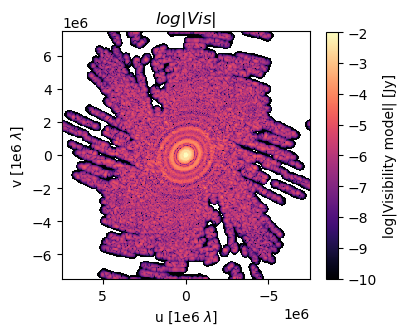

In [62]:
Plot_.visibility(fig_size = 4)

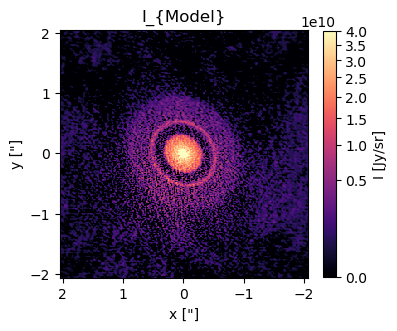

In [29]:
Plot_.intensity(fig_size = 4)

In [108]:
uv_table = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

Performing 1D Frank fit...


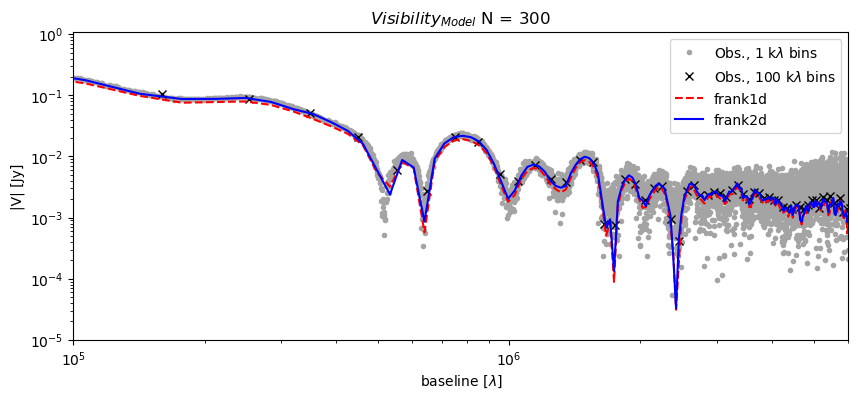

In [109]:
Plot_.visibility_profile(input = uv_table, weighted = True, frank1d = True)

In [110]:
dir =  "/Users/mariajmelladot/Desktop/Frank2D/data/fits/"
disk = disk_name + '_continuum.fits'
fits_file = dir + disk

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
Performing 1D Frank fit...


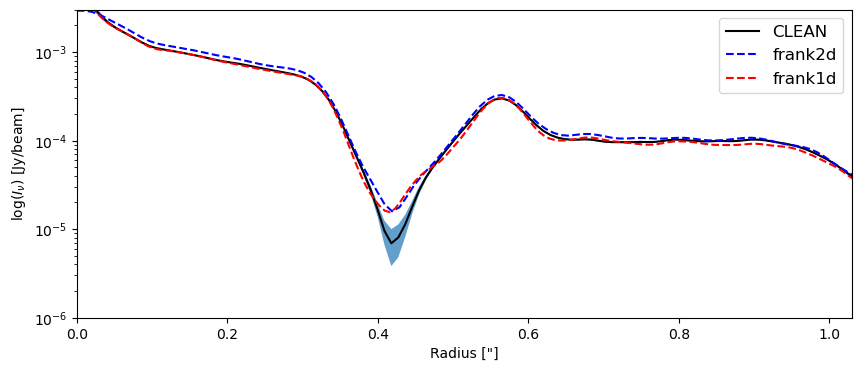

In [111]:
Plot_.intensity_profile(clean = True, fits_file = fits_file)

## Estimating the flux

In [11]:
u, v = frank2d.u_grid, frank2d.v_grid
vis = frank2d.visibility_model

In [12]:
index = np.where((u == 0) & (v == 0))
V_00 = vis[index].real
V_00

array([0.25531803])

In [13]:
x, y = frank2d.x_grid, frank2d.y_grid
I = frank2d.intensity_model

In [14]:
dx, dy = frank2d._FT._dx, frank2d._FT._dy

In [15]:
domega = dx * dy                      # sr por píxel (campo pequeño)
float(I.sum() * domega)   

0.2553180253097531

## Comparing CLEAN

In [16]:
from astropy.io import fits

dir =  "/Users/mariajmelladot/Desktop/Frank2D/data/fits/"
disk = disk_name + '_continuum.fits'

fits_name = dir + disk
fits_image = fits.open(fits_name)

## image

In [17]:
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse

from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u

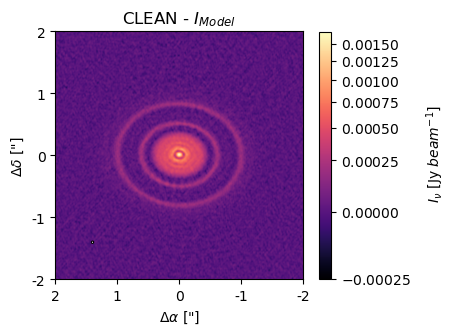

In [18]:
img_clean = np.squeeze(fits_image[0].data)
header = fits_image[0].header

bmaj_deg = float(header["BMAJ"])
bmin_deg = float(header["BMIN"])
bpa_deg  = float(header.get("BPA", 0.0))

pix_scale = np.round(abs(header['CDELT1']) * 3600, 6)  # arcsec/pixel
bmaj_as = np.radians(bmaj_deg) * 206265  # arcsec
bmin_as = np.radians(bmin_deg) * 206265  # arcsec
bpa_deg = header['BPA']

# tamaño del beam en PIXELES
bmaj_px = bmaj_as / pix_scale
bmin_px = bmin_as / pix_scale

center = len(img_clean)/2.
arcsec_to_px = 1/pix_scale  # px por arcsec

fig, ax = plt.subplots(figsize=(4,4))
im = ax.imshow(
    img_clean, cmap='magma',
    norm=colors.PowerNorm(gamma=0.45)
)

ax.set_xlim(center-2*arcsec_to_px, center+2*arcsec_to_px)
ax.set_ylim(center-2*arcsec_to_px, center+2*arcsec_to_px)

x0 = ax.get_xlim()[0] + 0.15*(ax.get_xlim()[1]-ax.get_xlim()[0])
y0 = ax.get_ylim()[0] + 0.15*(ax.get_ylim()[1]-ax.get_ylim()[0])

beam = Ellipse(
    (x0, y0),
    width=bmaj_px, height=bmin_px, angle=bpa_deg,
    facecolor='white', edgecolor='black', linewidth=0.8,
    zorder=5
)

ax.add_patch(beam)
ticks_x = [center-2*arcsec_to_px, center-1*arcsec_to_px, center, center+1*arcsec_to_px, center+2*arcsec_to_px]
ticks_y = [center-2*arcsec_to_px, center-1*arcsec_to_px, center, center+1*arcsec_to_px, center+2*arcsec_to_px]

cbar = fig.colorbar(im, shrink=0.8)
cbar.set_label(r' $I_{\nu}$ [Jy $beam^{-1}$]', rotation=90, labelpad=10)
from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(False)
formatter.set_powerlimits((0, 0)) 
cbar.ax.yaxis.set_major_formatter(formatter)


ax.set_xticks(ticks_x); ax.set_yticks(ticks_y)
ax.set_xticklabels([2,1,0,-1,-2]); ax.set_yticklabels([-2,-1,0,1,2])
ax.set_xlabel(r'$\Delta\alpha$ ["]'); ax.set_ylabel(r'$\Delta\delta$ ["]')
ax.set_title(r'CLEAN - $I_{Model}$')

plt.show()

In [19]:
img_clean.shape

(3000, 3000)

In [20]:
from astropy.coordinates import SkyCoord
import astropy.units as u

In [21]:
data   = fits.getdata(fits_name)

# WCS 2D solo de cielo
w = WCS(header).celestial

# Si tu data tiene más de 2 ejes, extrae el plano que te interesa
# (por ejemplo el primero en stokes y frecuencia)
if data.ndim > 2:
    sl = (0,)*(data.ndim-2) + (slice(None), slice(None))
    img_clean = np.asarray(data)[sl]
else:
    img_clean = np.asarray(data)

In [22]:
ny, nx = img_clean.shape
Xpix, Ypix = np.meshgrid(np.arange(nx), np.arange(ny), indexing="xy")

ra0, dec0 = header["CRVAL1"], header["CRVAL2"]
C0 = SkyCoord(ra=ra0*u.deg, dec=dec0*u.deg)

RA_deg, DEC_deg = w.pixel_to_world_values(Xpix, Ypix)
C = SkyCoord(ra=RA_deg*u.deg, dec=DEC_deg*u.deg)
dx, dy = C0.spherical_offsets_to(C)
X_as = dx.to(u.arcsec).value
Y_as = dy.to(u.arcsec).value
pts = np.stack([Y_as.ravel(), X_as.ravel()], axis=-1)

In [23]:
x_max = frank2d.x_grid.max()*rad_to_arcsec
y_max = frank2d.y_grid.max()*rad_to_arcsec
x_min = frank2d.x_grid.min()*rad_to_arcsec
y_min = frank2d.y_grid.min()*rad_to_arcsec

In [24]:
x_max

2.384

In [26]:
from scipy.ndimage import shift as ndshift


hdul   = fits.open(fits_name)
header = hdul[0].header
data   = np.squeeze(hdul[0].data).astype(float)

w = WCS(header).celestial  # WCS 2D del cielo

dX_as, dY_as = dra, ddec

hdr  = hdul[0].header.copy()
data = np.squeeze(hdul[0].data).astype(float)
w    = WCS(hdr).celestial

ny, nx = data.shape
xc, yc = (nx-1)/2.0, (ny-1)/2.0

# Mundo en el centro actual de imagen (pixel -> mundo)
ra_c, dec_c = w.pixel_to_world_values(xc, yc)
C0 = SkyCoord(ra_c*u.deg, dec_c*u.deg)

# Punto del cielo que debería caer en el centro tras aplicar el offset
C1 = C0.spherical_offsets_by(dX_as*u.arcsec, dY_as*u.arcsec)

# ¿Dónde cae C1 en la imagen actual? (mundo -> pixel)
x1, y1 = w.world_to_pixel(C1)

# Shift de píxeles necesario para llevar C1 al centro de la matriz
dx_pix = xc - x1
dy_pix = yc - y1

# Desplaza la data (subpíxel, interpolación cúbica)
data_shift = ndshift(data, shift=(dy_pix, dx_pix), order=3, mode="constant", cval=np.nan)

# Ajusta el WCS: si mueves la imagen +Δpix, debes mover CRPIX en sentido opuesto
hdr["CRPIX1"] = hdr["CRPIX1"] + dx_pix
hdr["CRPIX2"] = hdr["CRPIX2"] + dy_pix

In [27]:
data = data_shift

In [28]:

# --- mallas de pixel y offsets en arcsec (respecto a CRVAL) ---
ny, nx = data.shape
Xpix, Ypix = np.meshgrid(np.arange(nx), np.arange(ny), indexing="xy")

RA_deg, DEC_deg = w.pixel_to_world_values(Xpix, Ypix)
C0 = SkyCoord(header["CRVAL1"]*u.deg, header["CRVAL2"]*u.deg)
C  = SkyCoord(RA_deg*u.deg, DEC_deg*u.deg)
dx, dy = C0.spherical_offsets_to(C)         # en grados (incluye cos(dec))
X_as = dx.to(u.arcsec).value                # +X: Este, +Y: Norte
Y_as = dy.to(u.arcsec).value

# --- máscara ±2" y bounding box en píxeles ---
R = x_max  # arcsec
mask = (np.abs(X_as) <= R) & (np.abs(Y_as) <= R)
ys, xs = np.where(mask)

y0, y1 = ys.min(), ys.max() + 1
x0, x1 = xs.min(), xs.max() + 1

# --- recortes coherentes (data y mallas) ---
data_c = data[y0:y1, x0:x1]
X_as_c = X_as[y0:y1, x0:x1]
Y_as_c = Y_as[y0:y1, x0:x1]

In [29]:
clean_img = np.flipud(data_c)

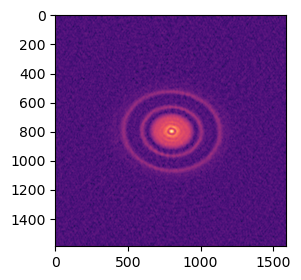

In [30]:
plt.figure(figsize=(3, 3))
norm = colors.PowerNorm(gamma=0.45)
plt.imshow(clean_img, cmap ='magma', norm=norm)
plt.show()

In [31]:
clean_img.shape

(1589, 1589)

In [32]:
X_as_c.max()

2.3820000004356476

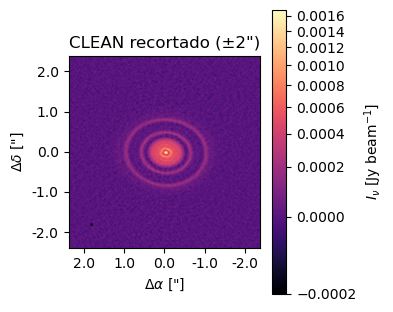

In [33]:
# --- WCS/Header consistente con el subcuadro ---
w_c   = w[y0:y1, x0:x1]        # WCS “rebanado” al mismo recorte
hdr_c = w_c.to_header()        # header celestial 2D del recorte

# Preserva keywords útiles (beam, unidades, etc.)
for k in ("BMAJ","BMIN","BPA","BUNIT","RESTFRQ","RESTFREQ","SPECSYS"):
    if k in header and k not in hdr_c:
        hdr_c[k] = header[k]

hdr_c.add_history(f"cropped to |X|<= {R} arcsec and |Y|<= {R} arcsec")
hdr_c.add_history(f"pixel slice: y={y0}:{y1}, x={x0}:{x1}")

# --- (opcional) guardar FITS recortado ---
fits_out = "Elias24_clean_cut.fits"
fits.writeto(fits_out, data_c.astype(np.float32), hdr_c, overwrite=True)

# --- (opcional) visualizar con ejes en arcsec y beam correcto ---
dy_deg_pix, dx_deg_pix = proj_plane_pixel_scales(w)[-2], proj_plane_pixel_scales(w)[-1]
bmaj_as = (float(header["BMAJ"])*u.deg).to(u.arcsec).value
bmin_as = (float(header["BMIN"])*u.deg).to(u.arcsec).value
bpa_deg = float(header.get("BPA", 0.0))
bmaj_px = bmaj_as / (abs(dx_deg_pix)*3600.0)
bmin_px = bmin_as / (abs(dy_deg_pix)*3600.0)
angle_display = 90.0 - bpa_deg  # convención Matplotlib (origin='lower')

# ticks en arcsec: busca pix más cercanos a [-2,-1,0,1,2]″
vals = np.array([-2,-1,0,1,2], float)
i0 = np.unravel_index(np.nanargmin(X_as**2 + Y_as**2), X_as.shape)
yc0, xc0 = i0
xticks = [np.argmin(np.abs(X_as[yc0, :] - v)) for v in vals]
yticks = [np.argmin(np.abs(Y_as[:, xc0] - v)) for v in vals]

fig, ax = plt.subplots(figsize=(4,4))
im = ax.imshow(data, origin='lower', cmap='magma', norm=colors.PowerNorm(gamma=0.45))
ax.set_xlim(x0, x1-1); ax.set_ylim(y0, y1-1)
xloc = x0 + 0.12*(x1-x0); yloc = y0 + 0.12*(y1-y0)
ax.add_patch(Ellipse((xloc, yloc), width=bmaj_px, height=bmin_px, angle=angle_display,
                     facecolor='white', edgecolor='black', linewidth=0.8, zorder=5))
ax.set_xticks(xticks); ax.set_yticks(yticks)
ax.set_xticklabels(vals); ax.set_yticklabels(vals)
ax.set_xlabel(r'$\Delta\alpha$ ["]'); ax.set_ylabel(r'$\Delta\delta$ ["]')
ax.set_title(r'CLEAN recortado (±2")')
cbar = fig.colorbar(im, shrink=0.8); cbar.set_label(r'$I_\nu$ [Jy beam$^{-1}$]')
plt.tight_layout(); plt.show()

In [34]:
x_arcsec, y_arcsec = frank2d.x*rad_to_arcsec, frank2d.y*rad_to_arcsec
extent_convention = [-x_arcsec[0], -x_arcsec[-1], -y_arcsec[-1], -y_arcsec[0]]
model = frank2d.intensity_model

In [35]:
# let's do a phase shift first.
u_ = frank2d.u_grid
v_ = frank2d.v_grid
vis_ = frank2d.visibility_model
vis = geom.apply_phase_shift(-u_, -v_, vis_)
I_shifted = frank2d.transform(vis).real

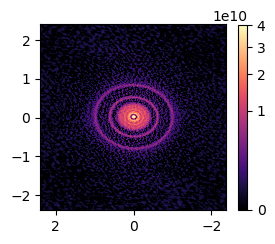

In [36]:
plt.figure(figsize=(3,3))
norm = colors.PowerNorm(gamma=0.45, vmin=0, vmax=4e10)
plt.imshow(I_shifted, cmap='magma',norm=norm, extent = extent_convention)
plt.colorbar(shrink = 0.8)

In [37]:
X_mod = frank2d.x_grid*rad_to_arcsec
Y_mod = frank2d.y_grid*rad_to_arcsec
M_mod = I_shifted

x_mod = -X_mod[0, :]
y_mod = Y_mod[:, 0]

In [40]:
import astropy.units as u
from astropy.convolution import convolve_fft, Gaussian2DKernel
from astropy.wcs.utils import proj_plane_pixel_scales
from scipy.interpolate import griddata
from scipy.interpolate import RegularGridInterpolator

# --- tienes: data_c, X_as_c, Y_as_c (arcsec), w_c (WCS del recorte) y hdr_c (header del recorte)
# --- y tu modelo tabulado: X_mod, Y_mod (2D o 1D expandido), M_mod (Jy/sr) con same shape que X_mod/Y_mod

# 1) INTERPOLAR MODELO (Jy/sr) A LA GRILLA DEL CLEAN RECORTADO (X_as_c, Y_as_c)

# Si X_mod, Y_mod son mallas 2D:
#pts_src   = np.c_[Y_mod.ravel(order='C'), X_mod.ravel(order='C')]               # (N,2) en orden (y,x)
#vals_src  = M_mod.ravel(order='C')                                     # (N,)
#pts_tgt   = np.c_[Y_as_c.ravel(order='C'), X_as_c.ravel(order='C')]             # (N_tgt,2)

#model_on_c_Jy_per_sr = griddata(
#    pts_src, vals_src, pts_tgt, method='linear', fill_value=np.nan
#).reshape(data_c.shape)

interp = RegularGridInterpolator(
    (y_mod, x_mod), M_mod,
    method="linear", bounds_error=False, fill_value=np.nan
)

# Puntos objetivo (Y, X) en arcsec, de la grilla CLEAN recortada
pts = np.stack([Y_as_c.ravel(order='C'), X_as_c.ravel(order='C')], axis=-1)

# Evalúa el modelo en la grilla CLEAN; resultado en Jy/sr
model_on_c_Jy_per_sr = interp(pts).reshape(data_c.shape)

# (si tu modelo está en una malla regular (x_mod 1D, y_mod 1D), puedes usar RegularGridInterpolator;
# con griddata funciona para cualquier malla 2D arbitraria.)

# 2) CONVOLUCIÓN CON EL BEAM RESTAURADOR (para igualar resolución)

# Parámetros del haz (FWHM mayor/menor en grados y posición del ángulo)
bmaj_deg = float(hdr_c["BMAJ"])
bmin_deg = float(hdr_c["BMIN"])
bpa_deg  = float(hdr_c.get("BPA", 0.0))

# Escalas de píxel proyectadas (deg/pix) del recorte (orden: (y, x))
dy_deg_pix, dx_deg_pix = proj_plane_pixel_scales(w_c)[-2], proj_plane_pixel_scales(w_c)[-1]

# FWHM (arcsec) → píxeles en ejes de imagen
bmaj_as = (bmaj_deg * u.deg).to(u.arcsec).value
bmin_as = (bmin_deg * u.deg).to(u.arcsec).value
fwhm_x_pix = bmaj_as / (abs(dx_deg_pix) * 3600.0)   # mayor en píxeles a lo largo de +x si BPA≈0
fwhm_y_pix = bmin_as / (abs(dy_deg_pix) * 3600.0)   # menor en píxeles a lo largo de +y si BPA≈0

# FWHM → sigma (en píxeles)
fwhm_to_sigma = 1.0 / (2.0*np.sqrt(2.0*np.log(2.0)))
sigma_x = fwhm_x_pix * fwhm_to_sigma
sigma_y = fwhm_y_pix * fwhm_to_sigma

# Ángulo del kernel: Gaussian2DKernel usa radianes CCW desde +X de imagen;
# BPA está medido desde el Norte hacia el Este → ángulo imagen = 90° - BPA
theta = np.deg2rad(90.0 - bpa_deg)

# Kernel gaussiano elíptico del haz
gk = Gaussian2DKernel(x_stddev=sigma_x, y_stddev=sigma_y, theta=theta, mode='oversample', factor=5)
kernel = gk.array / np.sum(gk.array)  # asegúrate de que suma 1

# Convolución (mantiene unidades Jy/sr)
model_conv_Jy_per_sr = convolve_fft(model_on_c_Jy_per_sr, kernel, allow_huge=True, normalize_kernel=True)

# 3) CONVERTIR Jy/sr → Jy/beam
# Área sólida del haz gaussiano: Ω = 2π σ_maj σ_min, con σ en radianes (ojo: ahora σ en rad, no en pix)
bmaj_rad = (bmaj_deg * u.deg).to(u.rad).value
bmin_rad = (bmin_deg * u.deg).to(u.rad).value
sigma_maj = bmaj_rad * fwhm_to_sigma
sigma_min = bmin_rad * fwhm_to_sigma
Omega_beam_sr = 2.0 * np.pi * sigma_maj * sigma_min  # [sr]

model_conv_Jy_per_beam = model_conv_Jy_per_sr * Omega_beam_sr

# 4) COMPARAR / RESIDUAL (ambos en Jy/beam)
residual = np.flipud(data_c) - model_conv_Jy_per_beam


In [41]:
from astropy.stats import sigma_clip
# --- Stats útiles ---
# residuales ya calculados: 'residual' (Jy/beam), con misma shape que data_c
finite = np.isfinite(residual)
res_vals = residual[finite]

# Clipping robusto: 3σ, hasta 5 iteraciones, centrado en la mediana
res_clip = sigma_clip(res_vals, sigma=3.0, maxiters=5, cenfunc="median", stdfunc="std")

# RMS del residual tras clipping
std = np.nanstd(res_clip)

print(f"RMS residual (clip): {std:.4g} Jy/beam")
print(f"Pico residual:      {np.nanmax(residual):.4g} Jy/beam")
print(f"Mín residual:       {np.nanmin(residual):.4g} Jy/beam")

RMS residual (clip): 1.987e-05 Jy/beam
Pico residual:      0.0008323 Jy/beam
Mín residual:       -0.0009095 Jy/beam


In [42]:
np.nanmax(residual)/std

41.896058479690204

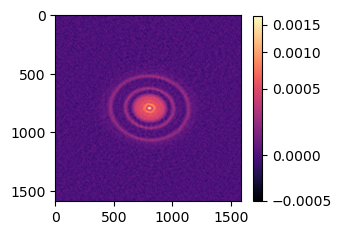

In [43]:
plt.figure(figsize=(3,3))
norm = colors.PowerNorm(gamma=0.45)
plt.imshow(np.flipud(data_c), cmap='magma', norm=norm)
plt.colorbar(shrink =0.8)

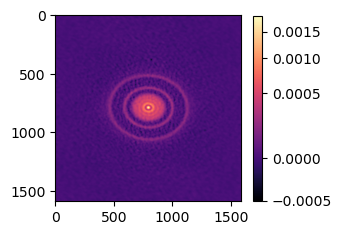

In [44]:
plt.figure(figsize=(3,3))
norm = colors.PowerNorm(gamma=0.45)
plt.imshow(model_conv_Jy_per_beam, cmap='magma', norm=norm)
plt.colorbar(shrink =0.8)

In [45]:
np.max(model_conv_Jy_per_beam)

0.001844782825808622

In [46]:
np.max(data_c)

0.0016802289960549312

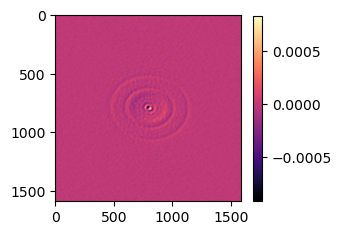

In [53]:
plt.figure(figsize=(3,3))
#norm = colors.PowerNorm(gamma=0.45)
plt.imshow(residual, cmap='magma') # norm=norm)
plt.colorbar(shrink = 0.8)

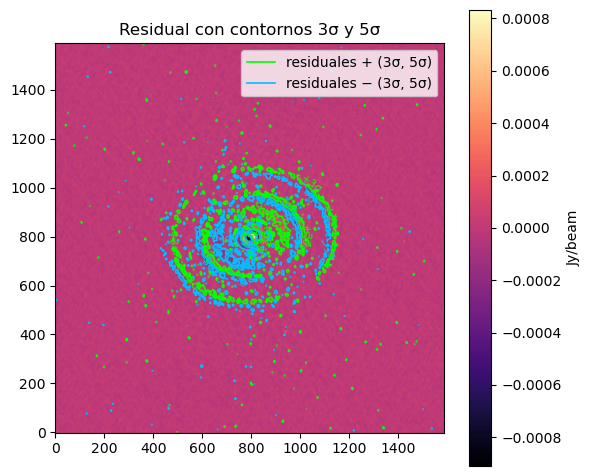

In [54]:
from astropy.stats import sigma_clip
import numpy as np
import matplotlib.lines as mlines

# Asumo que ya hiciste:
plt.figure(figsize=(6,6))
ax = plt.gca()
im = ax.imshow(residual, cmap='magma', origin='lower')
plt.colorbar(im, shrink=0.8).set_label('Jy/beam')

# --- RMS robusto ---
finite = np.isfinite(residual)
res_clip = sigma_clip(residual[finite], sigma=3.0, maxiters=5,
                      cenfunc="median", stdfunc="std")
rms = np.nanstd(res_clip)
if not np.isfinite(rms) or rms <= 0:
    raise RuntimeError("RMS inválido (NaN/0).")

# --- niveles en 3σ y 5σ ---
levels_pos = [3*rms, 5*rms]      # crecientes
levels_neg = [-5*rms, -3*rms]    # crecientes (¡ojo el orden!)

# Enmascara NaNs para contornear
res_plot = np.where(np.isfinite(residual), residual, 0.0)

# --- contornos ---
cs_pos = ax.contour(res_plot, levels=levels_pos, colors='lime',
                    linewidths=1.2, linestyles='solid')
cs_neg = ax.contour(res_plot, levels=levels_neg, colors='deepskyblue',
                    linewidths=1.2, linestyles='solid')

# Labels sobre las curvas
fmt_pos = {levels_pos[0]: "+3σ", levels_pos[1]: "+5σ"}
fmt_neg = {levels_neg[0]: "−5σ", levels_neg[1]: "−3σ"}
ax.clabel(cs_pos, inline=True, fontsize=8, fmt=fmt_pos)
ax.clabel(cs_neg, inline=True, fontsize=8, fmt=fmt_neg)

# Leyenda simple por color
leg_pos = mlines.Line2D([], [], color='lime', linewidth=1.2, label='residuales + (3σ, 5σ)')
leg_neg = mlines.Line2D([], [], color='deepskyblue', linewidth=1.2, label='residuales − (3σ, 5σ)')
ax.legend(handles=[leg_pos, leg_neg], loc='upper right', frameon=True)

ax.set_title("Residual con contornos 3σ y 5σ")
plt.tight_layout(); plt.show()

## profile

In [68]:
# Obtain the radial profiles convolved to a circular beam.
from gofish import imagecube

infile_1mm = fits_name
#2D->1D
cube_1mm = imagecube(infile_1mm)
inc, pa, dra, ddec = data['inc'], data['pa'], data['dra'], data['ddec']
x_1mm,y_1mm,dy_1mm = cube_1mm.radial_profile(inc= data['inc'], PA=data['pa'], x0=data['dra'], y0=data['ddec'])

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.


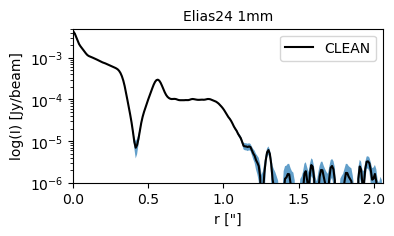

In [69]:
plt.figure(figsize=(4, 2))
plt.plot(x_1mm, y_1mm, "black", label = "CLEAN")
plt.fill_between(x_1mm, y_1mm-dy_1mm, y_1mm+dy_1mm,alpha=0.7)
plt.title(disk_name + r' 1mm', size=10)
plt.ylabel("log(I) [Jy/beam]", size=10)
plt.xlabel('r ["]', size=10)
plt.legend(fontsize=10)
plt.yscale('log')
plt.ylim(1e-6, 0.5e-2)
plt.xlim(0, rout)
plt.show()

In [70]:
# let's do a phase shift first.
u_ = frank2d.u_grid
v_ = frank2d.v_grid
vis_ = frank2d.visibility_model
vis = geom.apply_phase_shift(-u_, -v_, vis_)
I_shifted = frank2d.transform(vis).real

In [71]:
x_arcsec, y_arcsec = frank2d.x_grid*rad_to_arcsec, frank2d.y_grid*rad_to_arcsec
x_arcsec_1d, y_arcsec_1d = frank2d.x*rad_to_arcsec, frank2d.y*rad_to_arcsec
I = frank2d.intensity_model

In [72]:
intensity_model = I_shifted

In [75]:
x_arcsec_d, y_arcsec_d = geom.deproject_xy(frank2d.x_grid*rad_to_arcsec, frank2d.y_grid*rad_to_arcsec)
x_arcsec_1d_d, y_arcsec_1d_d = geom.deproject_xy( frank2d.x*rad_to_arcsec, frank2d.y*rad_to_arcsec)

In [76]:
bins = 300
r = np.unique(np.hypot(x_arcsec_1d_d, y_arcsec_1d_d))
r = np.linspace(r.min(), r.max(), bins)
r_edges = Plot_.edges(r)

In [77]:
r_model_1d, int_model_1d = Plot_.get_profile(x_arcsec_d, y_arcsec_d, intensity_model, r_edges )

In [78]:
int_model_1d = np.nan_to_num(int_model_1d, nan=0)/ np.cos(inc*deg_to_rad)

In [79]:
from frank.utilities import convolve_profile

header = fits_image[0].header

bmaj_deg = float(header["BMAJ"])
bmin_deg = float(header["BMIN"])
bmaj_as = bmaj_deg * 3600.0
bmin_as = bmin_deg * 3600.0
bpa_deg = header['BPA']

clean_beam_1mm = {'bmaj': bmaj_as, 'bmin': bmin_as, 'beam_pa': bpa_deg}
area_1mm = clean_beam_1mm['bmaj']*clean_beam_1mm['bmin']*np.pi/4./np.log(2.)*(1/rad_to_arcsec)**2

model_convolved = convolve_profile(r_model_1d, int_model_1d, inc, pa, clean_beam_1mm)*area_1mm

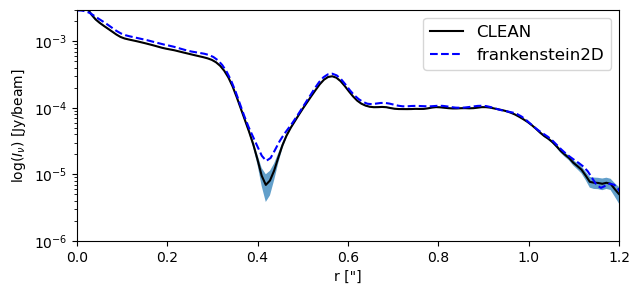

In [80]:
plt.figure(figsize=(7, 3))
plt.plot(x_1mm, y_1mm, "black", label = "CLEAN")
plt.fill_between(x_1mm, y_1mm-dy_1mm, y_1mm+dy_1mm,alpha=0.7)
plt.plot(r_model_1d, model_convolved, "blue", ls= '--', label=r'frankenstein2D')
plt.ylabel(r'log($I_\nu$) [Jy/beam]', size=10)
plt.xlabel('r ["]', size=10)
plt.legend(fontsize=12)
plt.yscale('log')
plt.ylim(1e-6, 3e-3)
plt.xlim(0,1.2)
plt.show()

In [157]:
alpha = 1.2
wsmooth = 1e-1

In [158]:
sol = frank2d.frank1d(alpha = alpha, w_smooth = wsmooth)

Performing 1D Frank fit...


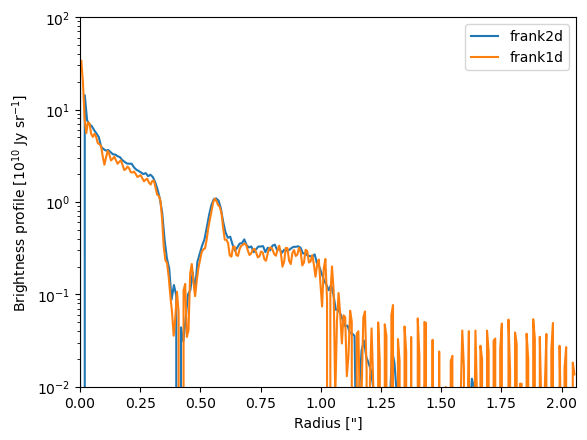

In [163]:
plt.plot(r_model_1d, int_model_1d/1e10, label = "frank2d")
plt.plot(sol.r, sol.mean/1e10,label ='frank1d')
plt.xlabel('Radius ["]', size = 10)
plt.ylabel(r'Brightness profile [$10^{10}$ Jy sr$^{-1}$]', size = 10)
plt.xlim(0, rout)
plt.ylim(1e-2, 1e2)
plt.yscale('log')
plt.legend()
plt.show()

In [164]:
convolved_1mm_frank1d = convolve_profile(sol.r, sol.mean, inc, pa, clean_beam_1mm)*area_1mm

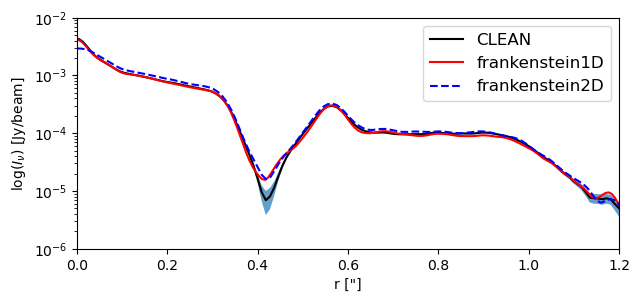

In [165]:
plt.figure(figsize=(7, 3))
plt.plot(x_1mm, y_1mm, "black", label = "CLEAN")
plt.fill_between(x_1mm, y_1mm-dy_1mm, y_1mm+dy_1mm,alpha=0.7)
plt.plot(sol.r, convolved_1mm_frank1d, "red", label=r'frankenstein1D')
plt.plot(r_model_1d, model_convolved, "blue", ls= '--', label=r'frankenstein2D')
plt.ylabel(r'log($I_\nu$) [Jy/beam]', size=10)
plt.xlabel('r ["]', size=10)
plt.legend(fontsize=12)
plt.yscale('log')
plt.ylim(1e-6, 1e-2)
plt.xlim(0,1.2)
plt.show()

# Errors frank2d

In [245]:
Dchol = scipy.linalg.cho_factor(Dinv) ## HACERLO CON BICGSTAB!!! INSTEAD
size = N*N
num_fields = 1

NameError: name 'Dinv' is not defined

In [ ]:
b = np.eye(size*num_fields)
cov = scipy.linalg.cho_solve(Dchol, b)

# Intrinsic resolution